In [1]:
# Import your libraries here

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import pipeline
from transformers import logging as hf_logging

In [2]:
current_dir = os.path.abspath("")
project_root = os.path.abspath(os.path.join(current_dir, "../"))

if project_root not in sys.path:
    sys.path.append(project_root)

os.chdir(project_root)

print(f"Working directory set to: {os.getcwd()}")

Working directory set to: D:\users\kamen.dimitrov\desktop\softuni\AI_and_ML_upskill_program\Data Science\08_final_project


In [37]:
# Import your modules here

import importlib

import src.plotting_utils.plotting_utils as plot_utils
from src.data_pipeline_utils import data_fetching_handling as data_pipe
import src.nlp_utils.nlp_utils as nlp_utils

importlib.reload(plot_utils)
importlib.reload(data_pipe)
importlib.reload(nlp_utils)

<module 'src.nlp_utils.nlp_utils' from 'D:\\users\\kamen.dimitrov\\desktop\\softuni\\AI_and_ML_upskill_program\\Data Science\\08_final_project\\src\\nlp_utils\\nlp_utils.py'>

#TODO - reference my Kaggle dataset - 
@misc{potterer_2021,
  title={Scraped Motley Fool Earnings Call Transcripts},
  url={https://www.kaggle.com/datasets/tpotterer/motley-fool-scraped-earnings-call-transcripts},
  journal={Kaggle},
  publisher={Kaggle},
  author={Potterer, T.},
  year={2021}
}

@misc{motley_fool_transcripts,
  title={Earnings Call Transcripts},
  url={https://www.fool.com/earnings-call-transcripts/},
  journal={The Motley Fool},
  author={{Motley Fool Transcribing}},
  year={2026},
  note={Accessed: 2026-03-27}
}

"The primary data for this study consists of 18,755 earnings call transcripts originally published by The Motley Fool. The dataset was accessed via a secondary distribution hosted on Kaggle (Potterer, 2021), covering a period from November 2017 to February 2023. This dataset includes full-text records of prepared remarks and Q&A sessions for [Number] unique tickers across various exchanges.

In [4]:
transcript_data = pd.read_pickle("static_data/motley-fool-data.pkl")
transcript_data

,date,exchange,q,ticker,transcript
0,"Aug 27, 2020, 9:00 p.m. ET",NASDAQ: BILI,2020-Q2,BILI,"Prepared Remarks:\nOperator\nGood day, and wel..."
1,"Jul 30, 2020, 4:30 p.m. ET",NYSE: GFF,2020-Q3,GFF,Prepared Remarks:\nOperator\nThank you for sta...
2,"Oct 23, 2019, 5:00 p.m. ET",NASDAQ: LRCX,2020-Q1,LRCX,Prepared Remarks:\nOperator\nGood day and welc...
3,"Nov 6, 2019, 12:00 p.m. ET",NASDAQ: BBSI,2019-Q3,BBSI,"Prepared Remarks:\nOperator\nGood day, everyon..."
4,"Aug 7, 2019, 8:30 a.m. ET",NASDAQ: CSTE,2019-Q2,CSTE,Prepared Remarks:\nOperator\nGreetings and wel...
...,...,...,...,...,...
18750,"Nov 9, 2021, 1:00 p.m. ET",NYSE: SWX,2021-Q3,SWX,Prepared Remarks:\nOperator\nLadies and gentle...
18751,"Nov 18, 2021, 12:00 p.m. ET",NYSE: PNNT,2021-Q4,PNNT,"Prepared Remarks:\nOperator\nGood morning, and..."
18752,"Feb 08, 2022, 11:00 a.m. ET",NYSE: TDG,2022-Q1,TDG,Prepared Remarks:\nOperator\nThank you for sta...
18753,"Feb 28, 2022, 4:30 p.m. ET",NASDAQ: DVAX,2021-Q4,DVAX,"Prepared Remarks:\nOperator\nGood day, ladies ..."


#TODO -> The date is in a horrible format, have to do work to transform it to pd.to_datetime(). Have to add explanations

In [5]:
transcript_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18755 entries, 0 to 18754
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        18755 non-null  object
 1   exchange    18755 non-null  object
 2   q           18755 non-null  object
 3   ticker      18755 non-null  object
 4   transcript  18755 non-null  object
dtypes: object(5)
memory usage: 732.7+ KB


In [6]:
transcript_data['date'].apply(type).value_counts()

date
<class 'str'>     18376
<class 'list'>      379
Name: count, dtype: int64

I have created a method with simple string manipulation to extract data in a new column called 'parsed_date' in Pandas datetime format. However the method returns 380 NaT results. 

In [7]:
transcript_data["parsed_date"] = transcript_data["date"].apply(
    data_pipe.custom_date_parsing_method
)
transcript_data

,date,exchange,q,ticker,transcript,parsed_date
0,"Aug 27, 2020, 9:00 p.m. ET",NASDAQ: BILI,2020-Q2,BILI,"Prepared Remarks:\nOperator\nGood day, and wel...",2020-08-27
1,"Jul 30, 2020, 4:30 p.m. ET",NYSE: GFF,2020-Q3,GFF,Prepared Remarks:\nOperator\nThank you for sta...,2020-07-30
2,"Oct 23, 2019, 5:00 p.m. ET",NASDAQ: LRCX,2020-Q1,LRCX,Prepared Remarks:\nOperator\nGood day and welc...,2019-10-23
3,"Nov 6, 2019, 12:00 p.m. ET",NASDAQ: BBSI,2019-Q3,BBSI,"Prepared Remarks:\nOperator\nGood day, everyon...",2019-11-06
4,"Aug 7, 2019, 8:30 a.m. ET",NASDAQ: CSTE,2019-Q2,CSTE,Prepared Remarks:\nOperator\nGreetings and wel...,2019-08-07
...,...,...,...,...,...,...
18750,"Nov 9, 2021, 1:00 p.m. ET",NYSE: SWX,2021-Q3,SWX,Prepared Remarks:\nOperator\nLadies and gentle...,2021-11-09
18751,"Nov 18, 2021, 12:00 p.m. ET",NYSE: PNNT,2021-Q4,PNNT,"Prepared Remarks:\nOperator\nGood morning, and...",2021-11-18
18752,"Feb 08, 2022, 11:00 a.m. ET",NYSE: TDG,2022-Q1,TDG,Prepared Remarks:\nOperator\nThank you for sta...,2022-02-08
18753,"Feb 28, 2022, 4:30 p.m. ET",NASDAQ: DVAX,2021-Q4,DVAX,"Prepared Remarks:\nOperator\nGood day, ladies ...",2022-02-28


In [8]:
transcript_data['parsed_date'].apply(type).value_counts()

parsed_date
<class 'pandas._libs.tslibs.timestamps.Timestamp'>    18375
<class 'pandas._libs.tslibs.nattype.NaTType'>           380
Name: count, dtype: int64

Checking the NaT results shows strings, which appear like list objects. I will employ regex to extract the pattern and then do string manipulation on the matched string.

In [9]:
transcript_data[ transcript_data['parsed_date'].isna() ]

,date,exchange,q,ticker,transcript,parsed_date
28,"[Brunswick (BC 0.66%) Q4 2018 , Jan. 31, 2019 ...",NYSE: BC,2018-Q4,BC,"Prepared Remarks:\nOperator\nGood morning, and...",NaT
125,"[Blucora (BCOR 1.57%) Q4 2018 , Feb. 14, 2019 ...",NASDAQ: BCOR,2018-Q4,BCOR,"Prepared Remarks:\nOperator\nGood day, ladies ...",NaT
154,"[Hoegh LNG Partners LP (HMLP)Q4 2018 , Feb. 2...",NYSE: HMLP,2018-Q4,HMLP,Prepared Remarks:\nOperator\nGood morning and ...,NaT
161,"[AECOM Technology (ACM 0.87%) Q1 2019 , Feb. 5...",NYSE: ACM,2019-Q1,ACM,Prepared Remarks:\nOperator\nGood morning and ...,NaT
235,"[GATX Corp (GATX 0.43%)Q4 2018 , Jan. 22, 201...",NYSE: GATX,2018-Q4,GATX,See all our earnings call transcripts.\nPrepar...,NaT
...,...,...,...,...,...,...
10936,[Mercury Computer Systems (MRCY -0.77%) Q2 201...,NASDAQ: MRCY,2018-Q2,MRCY,"Prepared Remarks:\nOperator\nGood day, everyon...",NaT
10969,"[Marinemax Inc (HZO 0.27%)Q1 2019 , Jan. 17, ...",NYSE: HZO,2019-Q1,HZO,See all our earnings call transcripts.\nPrepar...,NaT
10989,"[Deere & Company (DE 7.53%) Q4 2017 , Nov. 22,...",NYSE: DE,2017-Q4,DE,Prepared Remarks:\nOperator\nWelcome. Good mor...,NaT
11001,[Reliance Steel And Aluminum Co (RS 1.97%)Q3 ...,NYSE: RS,2018-Q3,RS,Prepared Remarks:\nOperator\nGreetings and wel...,NaT


In [10]:
# 1. Create a subset of only the failed rows
failed_parses = transcript_data[transcript_data['parsed_date'].isna()]

# 2. Count occurrences by ticker and show the top results
ticker_error_counts = failed_parses['ticker'].value_counts()

print("--- Top Tickers with Parsing Errors ---")
print(ticker_error_counts)

--- Top Tickers with Parsing Errors ---
ticker
PRGS      4
TOL       4
RMR       4
UHAL      3
GOOGL     3
         ..
RSG       1
ARI       1
XPO       1
DISC.A    1
MTOR      1
Name: count, Length: 277, dtype: int64


In [11]:
mask = transcript_data['parsed_date'].isna()

transcript_data.loc[mask, 'parsed_date'] = transcript_data.loc[mask, 'date'].astype(str).apply(
    data_pipe.custom_date_parsing_method_regex
)

transcript_data

,date,exchange,q,ticker,transcript,parsed_date
0,"Aug 27, 2020, 9:00 p.m. ET",NASDAQ: BILI,2020-Q2,BILI,"Prepared Remarks:\nOperator\nGood day, and wel...",2020-08-27
1,"Jul 30, 2020, 4:30 p.m. ET",NYSE: GFF,2020-Q3,GFF,Prepared Remarks:\nOperator\nThank you for sta...,2020-07-30
2,"Oct 23, 2019, 5:00 p.m. ET",NASDAQ: LRCX,2020-Q1,LRCX,Prepared Remarks:\nOperator\nGood day and welc...,2019-10-23
3,"Nov 6, 2019, 12:00 p.m. ET",NASDAQ: BBSI,2019-Q3,BBSI,"Prepared Remarks:\nOperator\nGood day, everyon...",2019-11-06
4,"Aug 7, 2019, 8:30 a.m. ET",NASDAQ: CSTE,2019-Q2,CSTE,Prepared Remarks:\nOperator\nGreetings and wel...,2019-08-07
...,...,...,...,...,...,...
18750,"Nov 9, 2021, 1:00 p.m. ET",NYSE: SWX,2021-Q3,SWX,Prepared Remarks:\nOperator\nLadies and gentle...,2021-11-09
18751,"Nov 18, 2021, 12:00 p.m. ET",NYSE: PNNT,2021-Q4,PNNT,"Prepared Remarks:\nOperator\nGood morning, and...",2021-11-18
18752,"Feb 08, 2022, 11:00 a.m. ET",NYSE: TDG,2022-Q1,TDG,Prepared Remarks:\nOperator\nThank you for sta...,2022-02-08
18753,"Feb 28, 2022, 4:30 p.m. ET",NASDAQ: DVAX,2021-Q4,DVAX,"Prepared Remarks:\nOperator\nGood day, ladies ...",2022-02-28


I am down to 1 instance of NaT in parsed_date. Unfortunately, this is really a case of empty 'date' field for this particular row.

In [12]:
transcript_data['parsed_date'].apply(type).value_counts()

parsed_date
<class 'pandas._libs.tslibs.timestamps.Timestamp'>    18754
<class 'pandas._libs.tslibs.nattype.NaTType'>             1
Name: count, dtype: int64

In [13]:
transcript_data[ transcript_data['parsed_date'].isna() ]

,date,exchange,q,ticker,transcript,parsed_date
416,,NYSE: XPO,2021-Q3,XPO,"Operator\nHello, and welcome to the XPO Logist...",NaT


I now have cleaned the date field, which is crucial for reaching the point I need. I would like to explore the characteristics of the transcripts. #TODO describe the statistics of the length.

In [14]:
transcript_data['transcript_len'] = transcript_data['transcript'].str.len()
transcript_data['transcript_len'].describe().T

count     18755.000000
mean      47303.002453
std       14686.474343
min        3616.000000
25%       37153.500000
50%       47930.000000
75%       56945.000000
max      188514.000000
Name: transcript_len, dtype: float64

I would like to explore the dates as well. #TODO - add explanations

In [15]:
min_date = transcript_data['parsed_date'].min()
max_date = transcript_data['parsed_date'].max()

print(f"Start Date: {min_date}")
print(f"End Date:   {max_date}")
print(f"Total Span: {max_date - min_date}")

Start Date: 2017-11-03 00:00:00
End Date:   2023-02-23 00:00:00
Total Span: 1938 days 00:00:00


count      64.000000
mean      293.031250
std       388.094284
min         3.000000
25%        32.250000
50%       135.000000
75%       356.250000
max      1540.000000
dtype: float64


<Axes: title={'center': 'Transcript Volume Over Time'}, xlabel='parsed_date'>

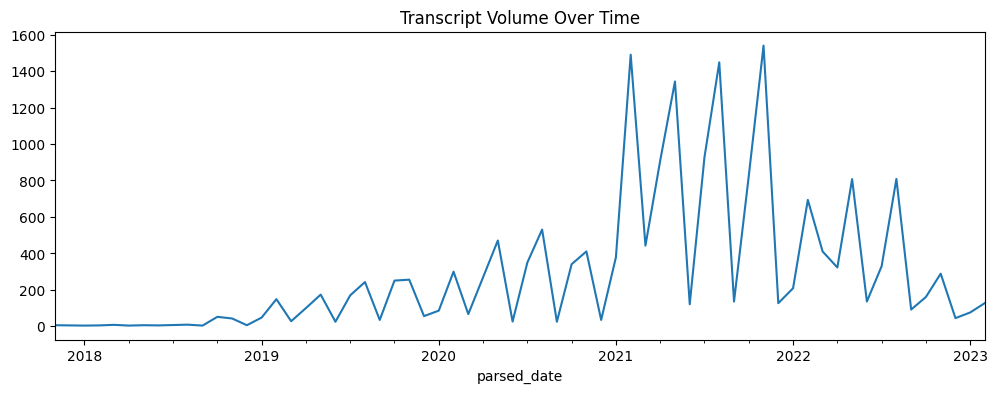

In [16]:
density = transcript_data.groupby(transcript_data['parsed_date'].dt.to_period('M')).size()
print(density.describe())

# Plotting the heartbeat
density.plot(kind='line', figsize=(12, 4), title='Transcript Volume Over Time')

@article{araci2019finbert,
  title={FinBERT: Financial Sentiment Analysis with Pre-trained Language Models},
  author={Araci, Dogu},
  journal={arXiv preprint arXiv:1908.10063},
  year={2019}
}

Hugging Face / ProsusAI Reference:

ProsusAI. (2020). FinBERT: A Pre-trained Strategy for Financial NLP. Hugging Face Model Hub. https://huggingface.co/ProsusAI/finbert

### 1. Methodology & Model Choice
To analyze the "Hard Data" provided in this repository, I utilized the **FinBERT** (`ProsusAI/finbert`) model—a pre-trained Natural Language Processing (NLP) model specifically fine-tuned for financial sentiment.

* **Task:** Classification of around 450 unique transcripts (cleaned from an original 18,755 row dataset).
* **Processing:** Each transcript (avg. 7,333 tokens) will be split into overlapping 512-token chunks.
* **Aggregation:** The final score will be the mean average of all chunks within a single transcript, providing a global sentiment value between -1 (Bearish) and 1 (Bullish).

The cell below will provide an example of what I intend to do.

### 2. Computational Hardware & Performance
Deep learning on large text blocks is computationally expensive. The results provided here will be generated using **GPU Acceleration** to ensure efficiency.

#### **Benchmark Comparison**
If you choose to recalculate these scores using the provided script, please be aware of the following estimated processing times:

| Environment | Device Type | Avg. Time per Score | Total Time (280) |
| :--- | :--- | :--- | :--- |
| **Standard Laptop** | Intel/AMD CPU | ~33.3 seconds | **~3.5 to 4 Hours** |
| **High-End PC** | NVIDIA GPU (CUDA) | ~0.5 seconds | **~5 to 7 Minutes** |
| **Cloud (Google Colab)** | Tesla T4 GPU | ~0.4 seconds | **~4 Minutes** |

> **Instruction:** If running on a "regular" machine (CPU), ensure the laptop is plugged into a power source and "Sleep Mode" is disabled. The fans will likely run at maximum speed during this process.

Let's see the example cell:

In [38]:
model_name = "ProsusAI/finbert"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

device = 0 if torch.cuda.is_available() else -1 
nlp = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=device)

sample_text = transcript_data.iloc[0]['transcript']
sentiment_results = nlp_utils.classify_long_transcript(sample_text, tokenizer, nlp)
print(sentiment_results)

final_score = nlp_utils.aggregate_sentiment(sentiment_results)
print(f"Aggregate Sentiment Score: {final_score:.4f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 'neutral', 'score': 0.9131340980529785}, {'label': 'positive', 'score': 0.9320159554481506}, {'label': 'positive', 'score': 0.6017572283744812}, {'label': 'positive', 'score': 0.9268548488616943}, {'label': 'positive', 'score': 0.8966866135597229}, {'label': 'positive', 'score': 0.9432780146598816}, {'label': 'positive', 'score': 0.9367685914039612}, {'label': 'neutral', 'score': 0.6806764602661133}, {'label': 'positive', 'score': 0.7548230290412903}, {'label': 'neutral', 'score': 0.5774754285812378}, {'label': 'positive', 'score': 0.8135058283805847}, {'label': 'positive', 'score': 0.6747928857803345}, {'label': 'positive', 'score': 0.8498713374137878}, {'label': 'neutral', 'score': 0.8503190279006958}, {'label': 'neutral', 'score': 0.8637856841087341}]
Aggregate Sentiment Score: 0.5554


Let's now see what reports are available for different stocks.

In [18]:
filtered_df = transcript_data[transcript_data['ticker'] == 'AAPL']

filtered_df

,date,exchange,q,ticker,transcript,parsed_date,transcript_len
46,"Apr 30, 2020, 5:00 p.m. ET",NASDAQ: AAPL,2020-Q2,AAPL,"Prepared Remarks:\nOperator\nGood day, everyon...",2020-04-30,48549
300,"Apr 30, 2020, 5:00 p.m. ET",NASDAQ: AAPL,2020-Q2,AAPL,"Prepared Remarks:\nOperator\nGood day, everyon...",2020-04-30,48549
406,"Apr 30, 2020, 5:00 p.m. ET",NASDAQ: AAPL,2020-Q2,AAPL,"Prepared Remarks:\nOperator\nGood day, everyon...",2020-04-30,48549
493,"Jul 28, 2022, 5:00 p.m. ET",NASDAQ: AAPL,2022-Q3,AAPL,"Prepared Remarks:\nOperator\nGood day, and wel...",2022-07-28,48337
604,"Jan 28, 2020, 5:00 p.m. ET",NASDAQ: AAPL,2020-Q1,AAPL,Prepared Remarks:\nOperator\nGood day everyone...,2020-01-28,48744
...,...,...,...,...,...,...,...
11937,"Jan 27, 2022, 5:00 p.m. ET",NASDAQ: AAPL,2022-Q1,AAPL,"Prepared Remarks:\nOperator\nGood day, and wel...",2022-01-27,49027
13072,"Oct 28, 2021, 5:00 p.m. ET",NASDAQ: AAPL,2021-Q4,AAPL,"Prepared Remarks:\nOperator\nGood day, and wel...",2021-10-28,53577
14317,"Feb 02, 2023, 5:00 p.m. ET",NASDAQ: AAPL,2023-Q1,AAPL,"Prepared Remarks:\nOperator\nGood day, everyon...",2023-02-02,49381
15320,"Apr 28, 2022, 5:00 p.m. ET",NASDAQ: AAPL,2022-Q2,AAPL,"Prepared Remarks:\nOperator\nGood day, and wel...",2022-04-28,50168


Something is not right, the date range is about 6 years, while stocks with sixty reports should cover more than 15 years. 

In [19]:
transcript_data.value_counts('ticker').nlargest(30)

ticker
AAPL     62
GOOGL    58
TSLA     52
AMZN     39
DIS      38
BEST     37
SE       27
MRNA     21
PTC      21
WWE      18
IBM      18
PARA     18
SQ       17
KO       17
BLK      17
YY       16
INTC     16
CLDT     16
CF       15
MGRC     15
COUP     15
AXL      15
CCL      15
ACM      15
WMT      15
EQIX     15
TTWO     15
PRGS     15
NTES     15
LQDT     14
Name: count, dtype: int64

Unfortunately, I have duplicate records. That's not good, I thought I really have more data. I will drop the duplicate values.

In [20]:
# 1. Filter for AAPL
aapl_df = transcript_data[transcript_data['ticker'] == 'AAPL'].copy()

# 2. Drop duplicates based on the transcript text itself (the most reliable way)
# or by date if your dates are already cleaned.
aapl_unique = aapl_df.drop_duplicates(subset=['transcript'], keep='first')

# 3. See the "True" count
print(f"Original AAPL rows: {len(aapl_df)}")
print(f"Unique AAPL reports: {len(aapl_unique)}")

Original AAPL rows: 62
Unique AAPL reports: 14


In [21]:
unique_transcript_data = transcript_data.drop_duplicates(subset=['ticker', 'transcript'])
unique_transcript_data.shape
unique_transcript_data

,date,exchange,q,ticker,transcript,parsed_date,transcript_len
0,"Aug 27, 2020, 9:00 p.m. ET",NASDAQ: BILI,2020-Q2,BILI,"Prepared Remarks:\nOperator\nGood day, and wel...",2020-08-27,35736
1,"Jul 30, 2020, 4:30 p.m. ET",NYSE: GFF,2020-Q3,GFF,Prepared Remarks:\nOperator\nThank you for sta...,2020-07-30,29761
2,"Oct 23, 2019, 5:00 p.m. ET",NASDAQ: LRCX,2020-Q1,LRCX,Prepared Remarks:\nOperator\nGood day and welc...,2019-10-23,53094
3,"Nov 6, 2019, 12:00 p.m. ET",NASDAQ: BBSI,2019-Q3,BBSI,"Prepared Remarks:\nOperator\nGood day, everyon...",2019-11-06,47532
4,"Aug 7, 2019, 8:30 a.m. ET",NASDAQ: CSTE,2019-Q2,CSTE,Prepared Remarks:\nOperator\nGreetings and wel...,2019-08-07,27273
...,...,...,...,...,...,...,...
18750,"Nov 9, 2021, 1:00 p.m. ET",NYSE: SWX,2021-Q3,SWX,Prepared Remarks:\nOperator\nLadies and gentle...,2021-11-09,42480
18751,"Nov 18, 2021, 12:00 p.m. ET",NYSE: PNNT,2021-Q4,PNNT,"Prepared Remarks:\nOperator\nGood morning, and...",2021-11-18,42787
18752,"Feb 08, 2022, 11:00 a.m. ET",NYSE: TDG,2022-Q1,TDG,Prepared Remarks:\nOperator\nThank you for sta...,2022-02-08,57044
18753,"Feb 28, 2022, 4:30 p.m. ET",NASDAQ: DVAX,2021-Q4,DVAX,"Prepared Remarks:\nOperator\nGood day, ladies ...",2022-02-28,36143


I will select the top 30 stocks based on the number of different quarterly earnings reports with transcripts available. I will extract a sample, which should be at least 440 rows. I will run a simulated yfinance download using the data pipeline functions in order to determine where I have the necessary data available and exclude delisted stocks. 

In [22]:
top_tickers = (unique_transcript_data['ticker'].value_counts().nlargest(40).index).to_list()
tickers_to_exclude = ['EXPR', 'GLYC', 'COUP', 'SKX', 'CDAY', 'NATI']
top_tickers = list(set(top_tickers) - set(tickers_to_exclude))
top_tickers

['NNN',
 'GPK',
 'AAPL',
 'RBA',
 'AZTA',
 'DIS',
 'BRX',
 'AXL',
 'ZBRA',
 'HWC',
 'STRA',
 'GIII',
 'ACCO',
 'SPSC',
 'SNAP',
 'WDFC',
 'GOOGL',
 'JOUT',
 'OTEX',
 'FTAI',
 'WOR',
 'KMB',
 'NWE',
 'CCL',
 'LIN',
 'FDX',
 'DLB',
 'FHB',
 'CPRT',
 'TOL',
 'ACM',
 'DAN',
 'MGRC',
 'UEIC']

In [23]:
final_dataset = unique_transcript_data [ unique_transcript_data['ticker'].isin(top_tickers) ]
final_dataset

,date,exchange,q,ticker,transcript,parsed_date,transcript_len
25,"May 4, 2021, 8:30 a.m. ET",NASDAQ: ZBRA,2021-Q1,ZBRA,"Prepared Remarks:\nOperator\nGood day, and wel...",2021-05-04,56321
46,"Apr 30, 2020, 5:00 p.m. ET",NASDAQ: AAPL,2020-Q2,AAPL,"Prepared Remarks:\nOperator\nGood day, everyon...",2020-04-30,48549
157,"Jan 25, 2021, 10:00 a.m. ET",NYSE: KMB,2020-Q4,KMB,Prepared Remarks:\nOperator\nLadies and gentle...,2021-01-25,61685
161,"[AECOM Technology (ACM 0.87%) Q1 2019 , Feb. 5...",NYSE: ACM,2019-Q1,ACM,Prepared Remarks:\nOperator\nGood morning and ...,2019-02-05,51782
163,"Feb 03, 2022, 5:00 p.m. ET",NYSE: SNAP,2021-Q4,SNAP,"Prepared Remarks:\nOperator\nGood afternoon, e...",2022-02-03,68017
...,...,...,...,...,...,...,...
18505,"Aug 04, 2022, 4:30 p.m. ET",NASDAQ: UEIC,2022-Q2,UEIC,Prepared Remarks:\nOperator\nGood afternoon. M...,2022-08-04,35786
18575,"Jul 28, 2021, 10:00 a.m. ET",NASDAQ: STRA,2021-Q2,STRA,Prepared Remarks:\nOperator\nWelcome to Strate...,2021-07-28,33030
18641,"Apr 22, 2022, 5:00 p.m. ET",NASDAQ: FHB,2022-Q1,FHB,"Prepared Remarks:\nOperator\nGood day, and tha...",2022-04-22,42958
18650,"Nov 01, 2022, 8:30 a.m. ET",NASDAQ: ZBRA,2022-Q3,ZBRA,Prepared Remarks:\nOperator\nGood day and welc...,2022-11-01,50065


In [24]:
final_dataset.to_csv("static_data/final_transcript_dataset.csv", index=False)

I ran the following command in Google Colab on a T4 GPU runtime environment, where the calculation was done in under 4 minutes despite having to make over 2000 NLP calls. I will leave the code commented, while the calculated data is available with the repo.

In [25]:
# final_dataset['sentiment_score'] = final_dataset['transcript'].apply(
#     lambda x: aggregate_sentiment(classify_long_transcript(x))
# )
# final_dataset.to_csv('final_transcript_dataset_with_sentiment.csv')

In [26]:
final_dataset_sentiment = pd.read_csv('static_data/final_transcript_dataset_with_sentiment.csv')
final_dataset_sentiment

,Unnamed: 0,date,exchange,q,ticker,transcript,parsed_date,transcript_len,sentiment_score
0,0,"May 4, 2021, 8:30 a.m. ET",NASDAQ: ZBRA,2021-Q1,ZBRA,"Prepared Remarks:\nOperator\nGood day, and wel...",2021-05-04,56321,0.372081
1,1,"Apr 30, 2020, 5:00 p.m. ET",NASDAQ: AAPL,2020-Q2,AAPL,"Prepared Remarks:\nOperator\nGood day, everyon...",2020-04-30,48549,0.121580
2,2,"Jan 25, 2021, 10:00 a.m. ET",NYSE: KMB,2020-Q4,KMB,Prepared Remarks:\nOperator\nLadies and gentle...,2021-01-25,61685,0.142763
3,3,"['AECOM Technology (ACM 0.87%) Q1 2019 ', 'Feb...",NYSE: ACM,2019-Q1,ACM,Prepared Remarks:\nOperator\nGood morning and ...,2019-02-05,51782,0.240139
4,4,"Feb 03, 2022, 5:00 p.m. ET",NYSE: SNAP,2021-Q4,SNAP,"Prepared Remarks:\nOperator\nGood afternoon, e...",2022-02-03,68017,0.416756
...,...,...,...,...,...,...,...,...,...
440,440,"Aug 04, 2022, 4:30 p.m. ET",NASDAQ: UEIC,2022-Q2,UEIC,Prepared Remarks:\nOperator\nGood afternoon. M...,2022-08-04,35786,0.122441
441,441,"Jul 28, 2021, 10:00 a.m. ET",NASDAQ: STRA,2021-Q2,STRA,Prepared Remarks:\nOperator\nWelcome to Strate...,2021-07-28,33030,0.163270
442,442,"Apr 22, 2022, 5:00 p.m. ET",NASDAQ: FHB,2022-Q1,FHB,"Prepared Remarks:\nOperator\nGood day, and tha...",2022-04-22,42958,-0.040500
443,443,"Nov 01, 2022, 8:30 a.m. ET",NASDAQ: ZBRA,2022-Q3,ZBRA,Prepared Remarks:\nOperator\nGood day and welc...,2022-11-01,50065,0.057728


I would like to obtain industry and sector information from yfinance for each represented stock

In [27]:
sector_data = [data_pipe.get_sector_industry(t) for t in top_tickers]
sector_df = pd.DataFrame(sector_data)
sector_df

,ticker,sector,industry
0,NNN,Real Estate,REIT - Retail
1,GPK,Consumer Cyclical,Packaging & Containers
2,AAPL,Technology,Consumer Electronics
3,RBA,Industrials,Specialty Business Services
4,AZTA,Healthcare,Medical Instruments & Supplies
5,DIS,Communication Services,Entertainment
6,BRX,Real Estate,REIT - Retail
7,AXL,Consumer Cyclical,Auto Parts
8,ZBRA,Technology,Communication Equipment
9,HWC,Financial Services,Banks - Regional


In [28]:
final_dataset_sentiment = final_dataset_sentiment.merge(sector_df, on='ticker', how='left')
final_dataset_sentiment.to_csv("static_data/final_transcript_dataset_with_sentiment.csv", index=False)
final_dataset_sentiment

,Unnamed: 0,date,exchange,q,ticker,transcript,parsed_date,transcript_len,sentiment_score,sector,industry
0,0,"May 4, 2021, 8:30 a.m. ET",NASDAQ: ZBRA,2021-Q1,ZBRA,"Prepared Remarks:\nOperator\nGood day, and wel...",2021-05-04,56321,0.372081,Technology,Communication Equipment
1,1,"Apr 30, 2020, 5:00 p.m. ET",NASDAQ: AAPL,2020-Q2,AAPL,"Prepared Remarks:\nOperator\nGood day, everyon...",2020-04-30,48549,0.121580,Technology,Consumer Electronics
2,2,"Jan 25, 2021, 10:00 a.m. ET",NYSE: KMB,2020-Q4,KMB,Prepared Remarks:\nOperator\nLadies and gentle...,2021-01-25,61685,0.142763,Consumer Defensive,Household & Personal Products
3,3,"['AECOM Technology (ACM 0.87%) Q1 2019 ', 'Feb...",NYSE: ACM,2019-Q1,ACM,Prepared Remarks:\nOperator\nGood morning and ...,2019-02-05,51782,0.240139,Industrials,Engineering & Construction
4,4,"Feb 03, 2022, 5:00 p.m. ET",NYSE: SNAP,2021-Q4,SNAP,"Prepared Remarks:\nOperator\nGood afternoon, e...",2022-02-03,68017,0.416756,Communication Services,Internet Content & Information
...,...,...,...,...,...,...,...,...,...,...,...
440,440,"Aug 04, 2022, 4:30 p.m. ET",NASDAQ: UEIC,2022-Q2,UEIC,Prepared Remarks:\nOperator\nGood afternoon. M...,2022-08-04,35786,0.122441,Technology,Consumer Electronics
441,441,"Jul 28, 2021, 10:00 a.m. ET",NASDAQ: STRA,2021-Q2,STRA,Prepared Remarks:\nOperator\nWelcome to Strate...,2021-07-28,33030,0.163270,Consumer Defensive,Education & Training Services
442,442,"Apr 22, 2022, 5:00 p.m. ET",NASDAQ: FHB,2022-Q1,FHB,"Prepared Remarks:\nOperator\nGood day, and tha...",2022-04-22,42958,-0.040500,Financial Services,Banks - Regional
443,443,"Nov 01, 2022, 8:30 a.m. ET",NASDAQ: ZBRA,2022-Q3,ZBRA,Prepared Remarks:\nOperator\nGood day and welc...,2022-11-01,50065,0.057728,Technology,Communication Equipment


In [29]:
final_dataset_sentiment['sentiment_score'].describe().T

count    445.000000
mean       0.140207
std        0.153174
min       -0.350929
25%        0.043979
50%        0.139780
75%        0.248288
max        0.604933
Name: sentiment_score, dtype: float64

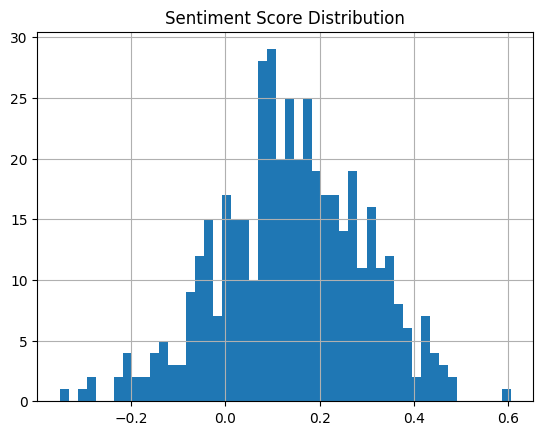

In [30]:
final_dataset_sentiment['sentiment_score'].hist(bins=50)
plt.title("Sentiment Score Distribution")
plt.show()

In [31]:
final_dataset_sentiment.groupby('ticker')['sentiment_score'].mean().sort_values(ascending=False)

ticker
AZTA     0.358077
ACM      0.293821
SNAP     0.274303
CCL      0.242817
OTEX     0.237023
ZBRA     0.215883
FDX      0.212176
MGRC     0.209822
RBA      0.202777
AAPL     0.199873
GOOGL    0.181653
DAN      0.179301
FTAI     0.162380
BRX      0.152048
SPSC     0.147465
JOUT     0.143422
WDFC     0.138016
GPK      0.130137
GIII     0.126944
NNN      0.117453
LIN      0.113918
KMB      0.111715
DIS      0.107675
UEIC     0.100088
TOL      0.088016
CPRT     0.084103
AXL      0.071492
STRA     0.057200
DLB      0.038235
HWC      0.032555
NWE      0.016234
ACCO     0.007139
WOR     -0.003517
FHB     -0.020221
Name: sentiment_score, dtype: float64

In [32]:
final_dataset_sentiment.groupby('ticker')['sentiment_score'].std().sort_values(ascending=False)

ticker
MGRC     0.266248
ACCO     0.238324
JOUT     0.221980
WDFC     0.202413
STRA     0.189120
WOR      0.180844
DAN      0.156011
SNAP     0.148951
AXL      0.145000
ZBRA     0.140737
FHB      0.130525
DLB      0.126060
CCL      0.116013
GIII     0.114648
GOOGL    0.113318
CPRT     0.112878
FDX      0.109541
TOL      0.109489
UEIC     0.106392
NWE      0.092535
RBA      0.092084
AAPL     0.088941
HWC      0.086295
KMB      0.084885
LIN      0.083521
NNN      0.077735
OTEX     0.074903
GPK      0.072241
FTAI     0.070678
ACM      0.060906
AZTA     0.055335
SPSC     0.052187
DIS      0.050010
BRX      0.046889
Name: sentiment_score, dtype: float64

<Axes: xlabel='date'>

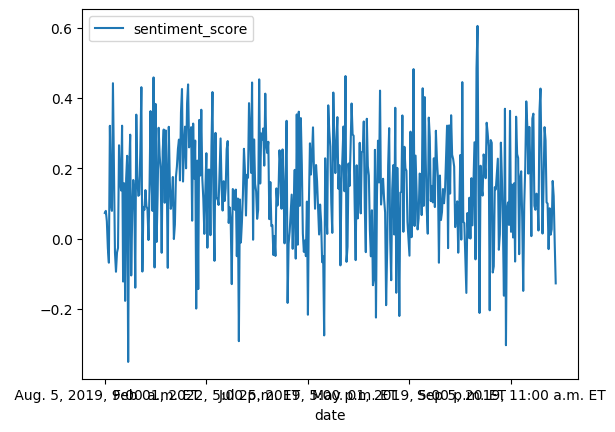

In [33]:
final_dataset_sentiment.sort_values('date').plot(x='date', y='sentiment_score')